In [13]:
import numpy as np
import torch
import torch.nn as nn
from matplotlib import pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, StratifiedKFold
from torch.utils.data.dataloader import DataLoader
from torch.utils.data.dataset import TensorDataset

plt.style.use("default")

In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [15]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False) # X: (70000, 784)

In [27]:
X, y = mnist["data"], mnist["target"]
X = torch.Tensor(X.astype(np.float32) / 255.0)
y = torch.Tensor(y.astype(np.int64))
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=10000, random_state=42, stratify=y
)
X_test = X_test.to(device)

In [17]:
X_trainval.shape

torch.Size([60000, 784])

In [18]:
train_dataset = TensorDataset(X_trainval.to(device), y_trainval.to(device))
test_dataset = TensorDataset(X_test.to(device), y_test.to(device))

test_loader = DataLoader(test_dataset, batch_size=1000)

In [19]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()

        self.input = nn.Linear(784, 2*784)
        self.hidden1 = nn.Linear(2*784, 2*784)
        self.hidden2 = nn.Linear(2*784, 2*784)
        self.output = nn.Linear(2*784, 10)
        self.relu = nn.ReLU()
        self.softmax = nn.LogSoftmax(dim=1)

        self.train_loss_per_epoch = None
        self.test_loss_per_epoch = None

    def forward(self, x):
        x = self.relu(self.input(x))
        x = self.relu(self.hidden1(x))
        x = self.relu(self.hidden2(x))
        x = self.output(x)
        x = self.softmax(x)
        return x

In [20]:
def train_one_model(max_epochs: int) -> MLP:
    model = MLP()
    model.to(device)
    model.train()

    loss_fn = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

    n_reports = 10
    print_every = max(max_epochs // n_reports, 1)

    train_loss_per_epoch = np.zeros(max_epochs)
    test_loss_per_epoch = np.zeros(max_epochs)

    for epoch in range(max_epochs):
        for data, target in train_loader:
            optimizer.zero_grad()

            y_pred = model(data)

            loss = loss_fn(y_pred, target.long())
            loss.backward()

            optimizer.step()

        model.eval()

        with torch.no_grad():
            loss = 0.0

            for data, target in train_loader:
                y_pred = model(data)
                loss += loss_fn(y_pred, target.long()).item()

            loss_avg = loss / len(train_loader)
            train_loss_per_epoch[epoch] = loss_avg

            loss = 0.0

            for data, target in test_loader:
                y_pred = model(data)
                loss += loss_fn(y_pred, target.long()).item()

            loss_avg = loss / len(test_loader)
            test_loss_per_epoch[epoch] = loss_avg

            if epoch % print_every == 0:
                print(f"{epoch=}\tCrossEntropy = {loss_avg:.3f}")

        model.train()

    model.train_loss_per_epoch = train_loss_per_epoch
    model.test_loss_per_epoch = test_loss_per_epoch

    model.eval()
    return model

In [29]:
batch_sizes = [
    1024,
    512,
    256,
    128,
    64,
    32,
    16,
]

models = []

for batch_size in batch_sizes:
    # Override global train_loader
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    model = train_one_model(10)
    models.append(model)

epoch=0	CrossEntropy = 1.796
epoch=1	CrossEntropy = 0.657
epoch=2	CrossEntropy = 0.488
epoch=3	CrossEntropy = 0.369
epoch=4	CrossEntropy = 0.340
epoch=5	CrossEntropy = 0.304
epoch=6	CrossEntropy = 0.284
epoch=7	CrossEntropy = 0.253
epoch=8	CrossEntropy = 0.240
epoch=9	CrossEntropy = 0.236
epoch=0	CrossEntropy = 0.671
epoch=1	CrossEntropy = 0.420
epoch=2	CrossEntropy = 0.303
epoch=3	CrossEntropy = 0.276
epoch=4	CrossEntropy = 0.238
epoch=5	CrossEntropy = 0.225
epoch=6	CrossEntropy = 0.196
epoch=7	CrossEntropy = 0.240
epoch=8	CrossEntropy = 0.173
epoch=9	CrossEntropy = 0.151
epoch=0	CrossEntropy = 0.389
epoch=1	CrossEntropy = 0.272
epoch=2	CrossEntropy = 0.208
epoch=3	CrossEntropy = 0.173
epoch=4	CrossEntropy = 0.170
epoch=5	CrossEntropy = 0.144
epoch=6	CrossEntropy = 0.108
epoch=7	CrossEntropy = 0.127
epoch=8	CrossEntropy = 0.104
epoch=9	CrossEntropy = 0.113
epoch=0	CrossEntropy = 0.284
epoch=1	CrossEntropy = 0.169
epoch=2	CrossEntropy = 0.130
epoch=3	CrossEntropy = 0.119
epoch=4	CrossE

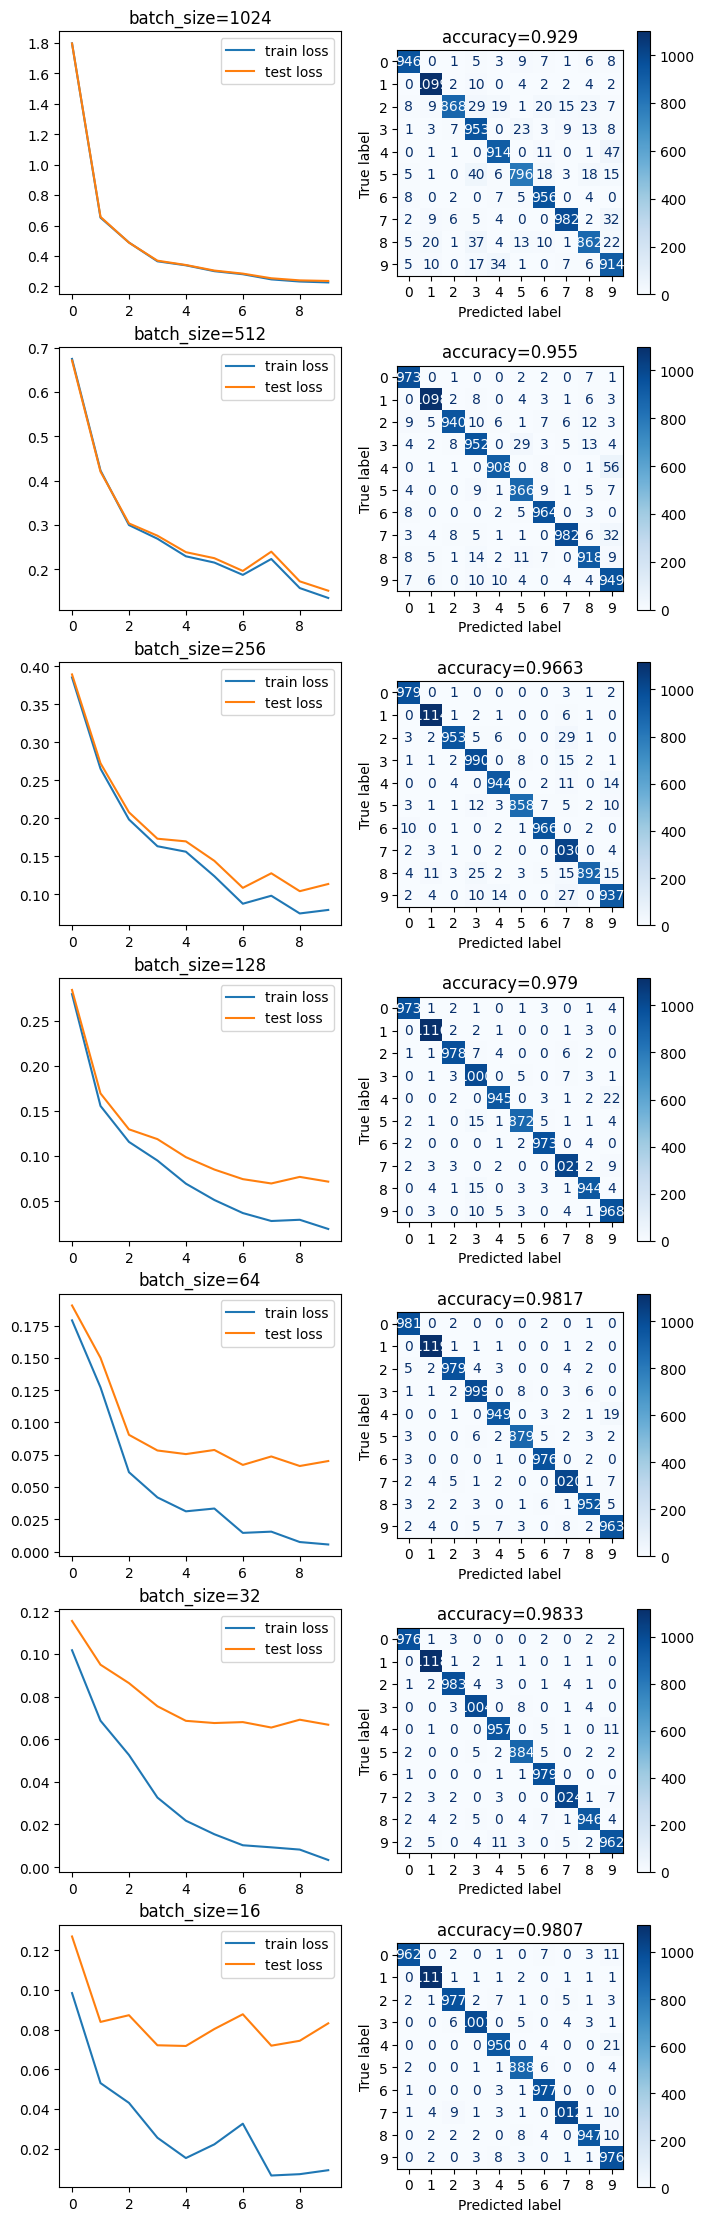

In [30]:
fig, axs = plt.subplots(len(models), 2, figsize=(4*2, 4*len(models)))

for idx, model in enumerate(models):
    batch_size = batch_sizes[idx]

    ax = axs[idx, 0]
    ax.plot(np.arange(len(model.train_loss_per_epoch)), model.train_loss_per_epoch, label="train loss")
    ax.plot(np.arange(len(model.test_loss_per_epoch)), model.test_loss_per_epoch, label="test loss")
    ax.legend()
    ax.set_title(f"{batch_size=}")

    ax = axs[idx, 1]
    with torch.no_grad():
        y_pred = model(X_test)
        y_pred = np.argmax(y_pred.detach().cpu(), axis=1)
        accuracy = accuracy_score(y_pred, y_test)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", ax=ax)
    ax.set_title(f"{accuracy=}")

plt.show()